# Modelo CNN con Transfer Learning - Dataset Balanceado

Version 2: Implementación con Transfer Learning usando MobileNetV2 para clasificación multietiqueta de productos de supermercado con dataset balanceado.

In [36]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Configuración
IMAGE_SIZE = (224, 224)  # Tamaño estándar para MobileNetV2
BATCH_SIZE = 32
EPOCHS = 20

print("Librerías importadas")

Librerías importadas


In [37]:
# Cargar anotaciones
train_df = pd.read_csv('../../Dataset-SupermarketImages/annotations_multietiqueta.csv')
val_df = pd.read_csv('../../Dataset-SupermarketImages/annotations_val_multietiqueta.csv')

print(f"DATOS ORIGINALES:")
print(f"Entrenamiento: {len(train_df)} muestras")
print(f"Validación: {len(val_df)} muestras")
print(f"Clases: {list(train_df.columns[1:])}")

# Análisis de distribución por clase
print(f"\n DISTRIBUCIÓN POR CLASE (ANTES DEL BALANCEADO):")
for col in train_df.columns[1:]:
    count = train_df[col].sum()
    print(f"  {col}: {count} muestras")

DATOS ORIGINALES:
Entrenamiento: 940 muestras
Validación: 60 muestras
Clases: ['Banana', 'Orange', 'Red-Bell-Pepper', 'aluminium-form', 'bread', 'cocaCola', 'doritos', 'red-bull', 'shampoo-H&S', 'tea', 'yogurt-toni-mix']

 DISTRIBUCIÓN POR CLASE (ANTES DEL BALANCEADO):
  Banana: 90 muestras
  Orange: 90 muestras
  Red-Bell-Pepper: 90 muestras
  aluminium-form: 90 muestras
  bread: 90 muestras
  cocaCola: 90 muestras
  doritos: 90 muestras
  red-bull: 90 muestras
  shampoo-H&S: 90 muestras
  tea: 90 muestras
  yogurt-toni-mix: 90 muestras


In [38]:
# BALANCEADO DEL DATASET
def balance_dataset(df, target_samples=100):
    """
    Balancea el dataset para tener un número similar de muestras por clase
    """
    balanced_rows = []
    
    for col in df.columns[1:]:  # Excluir columna 'image'
        # Obtener filas donde esta clase es positiva
        class_rows = df[df[col] == 1]
        
        if len(class_rows) >= target_samples:
            # Si hay suficientes muestras, tomar una muestra aleatoria
            sampled_rows = class_rows.sample(n=target_samples, random_state=42)
        else:
            # Si no hay suficientes, tomar todas las disponibles
            sampled_rows = class_rows
            print(f" {col}: Solo {len(class_rows)} muestras disponibles (objetivo: {target_samples})")
        
        balanced_rows.append(sampled_rows)
    
    # Combinar todas las filas y eliminar duplicados
    balanced_df = pd.concat(balanced_rows, ignore_index=True)
    balanced_df = balanced_df.drop_duplicates(subset=['image'], keep='first')
    
    return balanced_df

# Aplicar balanceado
print(" BALANCEANDO DATASET...")
train_balanced = balance_dataset(train_df, target_samples=85)  # Ajustar según disponibilidad

print(f"\n DATASET BALANCEADO:")
print(f"Entrenamiento balanceado: {len(train_balanced)} muestras")

# Verificar nueva distribución
print(f"\n NUEVA DISTRIBUCIÓN POR CLASE:")
for col in train_balanced.columns[1:]:
    count = train_balanced[col].sum()
    print(f"  {col}: {count} muestras")

 BALANCEANDO DATASET...

 DATASET BALANCEADO:
Entrenamiento balanceado: 888 muestras

 NUEVA DISTRIBUCIÓN POR CLASE:
  Banana: 85 muestras
  Orange: 85 muestras
  Red-Bell-Pepper: 85 muestras
  aluminium-form: 85 muestras
  bread: 85 muestras
  cocaCola: 85 muestras
  doritos: 85 muestras
  red-bull: 85 muestras
  shampoo-H&S: 85 muestras
  tea: 85 muestras
  yogurt-toni-mix: 85 muestras


In [39]:
# Función para cargar imágenes con preprocesamiento para Transfer Learning
def load_images_and_labels_tl(df, base_path='../../Dataset-SupermarketImages', image_size=IMAGE_SIZE):
    images = []
    labels = []
    failed_images = 0
    
    for idx, row in df.iterrows():
        img_path = os.path.join(base_path, row['image'])
        
        if not os.path.exists(img_path):
            failed_images += 1
            continue
            
        img = cv2.imread(img_path)
        if img is None:
            failed_images += 1
            continue
            
        # Preprocesamiento específico para MobileNetV2
        img = cv2.resize(img, image_size)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Normalización para MobileNetV2 (valores entre -1 y 1)
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        
        images.append(img)
        labels.append(row[1:].values.astype(np.float32))
    
    print(f" Imágenes cargadas: {len(images)} / {len(df)} (fallos: {failed_images})")
    
    return np.array(images), np.array(labels)

# Cargar datasets balanceados
print(" CARGANDO IMÁGENES CON PREPROCESAMIENTO TRANSFER LEARNING...")
x_train, y_train = load_images_and_labels_tl(train_balanced)
x_val, y_val = load_images_and_labels_tl(val_df)

print(f"\n FORMAS DE LOS DATOS:")
print(f"X_train: {x_train.shape} - Y_train: {y_train.shape}")
print(f"X_val: {x_val.shape} - Y_val: {y_val.shape}")

# Verificar distribución final
if len(y_train) > 0 and len(y_val) > 0:
    print(f"\n DISTRIBUCIÓN FINAL:")
    for i, col in enumerate(train_balanced.columns[1:]):
        train_count = y_train[:, i].sum()
        val_count = y_val[:, i].sum()
        print(f"  {col}: train={int(train_count)}, val={int(val_count)}")
else:
    print("\n No se cargaron imágenes. Verificar rutas.")

 CARGANDO IMÁGENES CON PREPROCESAMIENTO TRANSFER LEARNING...
 Imágenes cargadas: 888 / 888 (fallos: 0)
 Imágenes cargadas: 888 / 888 (fallos: 0)
 Imágenes cargadas: 60 / 60 (fallos: 0)

 FORMAS DE LOS DATOS:
X_train: (888, 224, 224, 3) - Y_train: (888, 11)
X_val: (60, 224, 224, 3) - Y_val: (60, 11)

 DISTRIBUCIÓN FINAL:
  Banana: train=85, val=6
  Orange: train=85, val=5
  Red-Bell-Pepper: train=85, val=5
  aluminium-form: train=85, val=5
  bread: train=85, val=5
  cocaCola: train=85, val=9
  doritos: train=85, val=9
  red-bull: train=85, val=5
  shampoo-H&S: train=85, val=5
  tea: train=85, val=5
  yogurt-toni-mix: train=85, val=5
 Imágenes cargadas: 60 / 60 (fallos: 0)

 FORMAS DE LOS DATOS:
X_train: (888, 224, 224, 3) - Y_train: (888, 11)
X_val: (60, 224, 224, 3) - Y_val: (60, 11)

 DISTRIBUCIÓN FINAL:
  Banana: train=85, val=6
  Orange: train=85, val=5
  Red-Bell-Pepper: train=85, val=5
  aluminium-form: train=85, val=5
  bread: train=85, val=5
  cocaCola: train=85, val=9
  doritos

In [40]:
# 🚀 CREAR MODELO CON TRANSFER LEARNING (MobileNetV2)

# Cargar modelo base pre-entrenado
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Congelar capas del modelo base
base_model.trainable = False

# Obtener número de clases
num_classes = len(train_balanced.columns) - 1
print(f" Número de clases: {num_classes}")
print(f" Clases: {list(train_balanced.columns[1:])}")

# Crear modelo completo
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='sigmoid')(x)  # sigmoid para multi-etiqueta

model = Model(inputs, outputs)

print(f"\n ARQUITECTURA DEL MODELO:")
model.summary()

print(f"\n PARÁMETROS:")
print(f"  Total: {model.count_params():,}")
# print(f"  Entrenables: {sum(p.numel() for p in model.trainable_variables):,}")
# print(f"  Congelados: {base_model.count_params():,}")

 Número de clases: 11
 Clases: ['Banana', 'Orange', 'Red-Bell-Pepper', 'aluminium-form', 'bread', 'cocaCola', 'doritos', 'red-bull', 'shampoo-H&S', 'tea', 'yogurt-toni-mix']

 ARQUITECTURA DEL MODELO:
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_4 (Dropout)         (None, 1280)              0         
                                                        

In [41]:
#  COMPILACIÓN Y CONFIGURACIÓN
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Compilar modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Para clasificación multi-etiqueta
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_lr=1e-7
)

callbacks = [early_stop, reduce_lr]

print(" MODELO COMPILADO Y CONFIGURADO")
print(" Callbacks: EarlyStopping + ReduceLROnPlateau")
print(" Loss: binary_crossentropy (multi-etiqueta)")
print(" Optimizer: Adam (lr=0.001)")

 MODELO COMPILADO Y CONFIGURADO
 Callbacks: EarlyStopping + ReduceLROnPlateau
 Loss: binary_crossentropy (multi-etiqueta)
 Optimizer: Adam (lr=0.001)


In [42]:
# 🏋️ ENTRENAMIENTO DEL MODELO

print(f" Datos: {len(x_train)} muestras de entrenamiento, {len(x_val)} de validación")
print(f" Configuración: batch_size={BATCH_SIZE}, epochs={EPOCHS}")
print("=" * 60)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


 Datos: 888 muestras de entrenamiento, 60 de validación
 Configuración: batch_size=32, epochs=20
Epoch 1/20
Epoch 1/20
28/28 [==============================] - 4s 64ms/step - loss: 0.3155 - accuracy: 0.4414 - val_loss: 0.0824 - val_accuracy: 0.9333 - lr: 0.0010
Epoch 2/20
28/28 [==============================] - 4s 64ms/step - loss: 0.3155 - accuracy: 0.4414 - val_loss: 0.0824 - val_accuracy: 0.9333 - lr: 0.0010
Epoch 2/20
28/28 [==============================] - 1s 36ms/step - loss: 0.0934 - accuracy: 0.8761 - val_loss: 0.0308 - val_accuracy: 0.9833 - lr: 0.0010
Epoch 3/20
28/28 [==============================] - 1s 36ms/step - loss: 0.0934 - accuracy: 0.8761 - val_loss: 0.0308 - val_accuracy: 0.9833 - lr: 0.0010
Epoch 3/20
28/28 [==============================] - 1s 37ms/step - loss: 0.0510 - accuracy: 0.9437 - val_loss: 0.0169 - val_accuracy: 0.9667 - lr: 0.0010
Epoch 4/20
28/28 [==============================] - 1s 37ms/step - loss: 0.0510 - accuracy: 0.9437 - val_loss: 0.0169 - va


 REPORTE DE CLASIFICACIÓN:
                 precision    recall  f1-score   support

         Banana       1.00      1.00      1.00         6
         Orange       1.00      1.00      1.00         5
Red-Bell-Pepper       1.00      1.00      1.00         5
 aluminium-form       1.00      1.00      1.00         5
          bread       1.00      1.00      1.00         5
       cocaCola       1.00      1.00      1.00         9
        doritos       1.00      1.00      1.00         9
       red-bull       1.00      1.00      1.00         5
    shampoo-H&S       1.00      1.00      1.00         5
            tea       1.00      1.00      1.00         5
yogurt-toni-mix       1.00      1.00      1.00         5

      micro avg       1.00      1.00      1.00        64
      macro avg       1.00      1.00      1.00        64
   weighted avg       1.00      1.00      1.00        64
    samples avg       1.00      1.00      1.00        64


 MÉTRICAS MULTI-ETIQUETA:
  Hamming Loss: 0.0000
  Subse

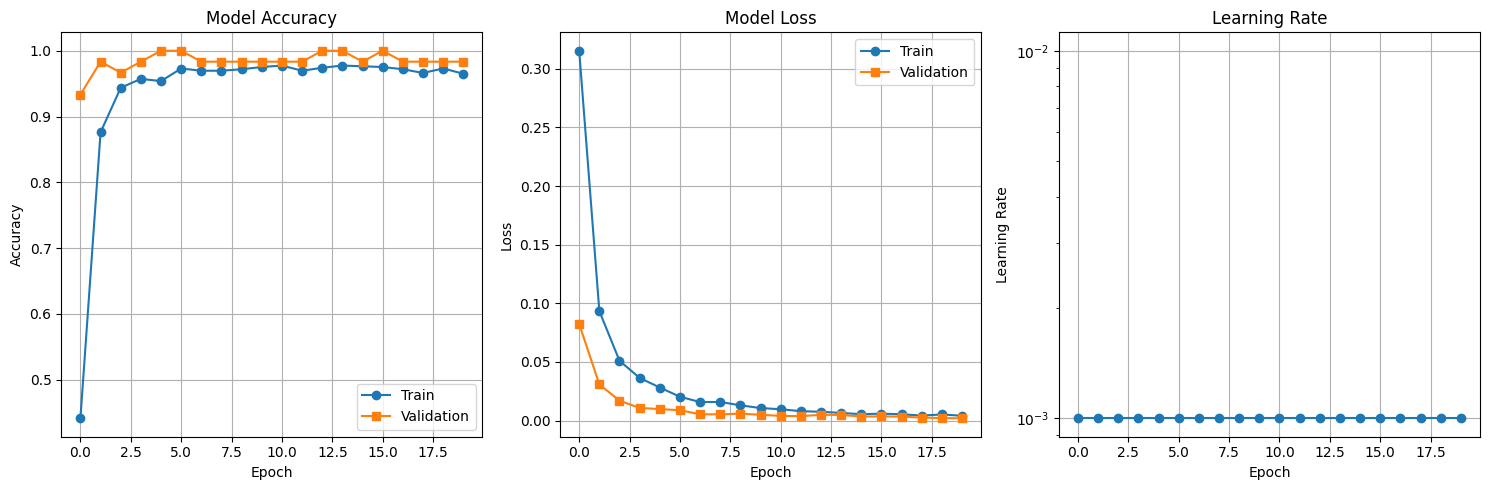


 RESULTADOS FINALES:
  Train Accuracy: 0.9651
  Val Accuracy: 0.9833
  Train Loss: 0.0041
  Val Loss: 0.0019


In [48]:
#  EVALUACIÓN Y MÉTRICAS
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

# Predicciones
y_pred = model.predict(x_val, verbose=0)
y_pred_bin = (y_pred > 0.5).astype(int)

# Métricas
print("\n REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_val, y_pred_bin, 
                          target_names=list(train_balanced.columns[1:]), 
                          zero_division=0))

# Métricas adicionales para multi-etiqueta
hamming = hamming_loss(y_val, y_pred_bin)
subset_acc = accuracy_score(y_val, y_pred_bin)

print(f"\n MÉTRICAS MULTI-ETIQUETA:")
print(f"  Hamming Loss: {hamming:.4f}")
print(f"  Subset Accuracy: {subset_acc:.4f}")

# Gráficas de entrenamiento
plt.figure(figsize=(15, 5))

# Accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train', marker='o')
plt.plot(history.history['val_loss'], label='Validation', marker='s')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Learning Rate
plt.subplot(1, 3, 3)
if 'lr' in history.history:
    plt.plot(history.history['lr'], marker='o')
    plt.title('Learning Rate')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True)
else:
    plt.text(0.5, 0.5, 'Learning Rate\nno disponible', ha='center', va='center')
    plt.title('Learning Rate')

plt.tight_layout()
plt.show()

# Métricas finales
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\n RESULTADOS FINALES:")
print(f"  Train Accuracy: {final_train_acc:.4f}")
print(f"  Val Accuracy: {final_val_acc:.4f}")
print(f"  Train Loss: {final_train_loss:.4f}")
print(f"  Val Loss: {final_val_loss:.4f}")

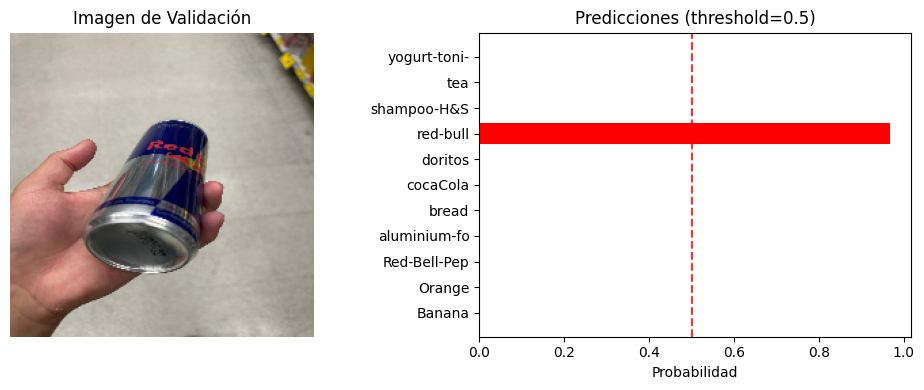


 RESULTADOS DE LA PRUEBA:
  Etiquetas verdaderas: ['red-bull']
  Etiquetas predichas: ['red-bull']

 TOP-3 PREDICCIONES:
  1. red-bull: 0.968
  2. yogurt-toni-mix: 0.003
  3. cocaCola: 0.000


In [44]:
# PRUEBA CON IMAGEN ALEATORIA
import random

# Seleccionar imagen aleatoria del conjunto de validación
idx = random.randint(0, len(x_val)-1)
img = x_val[idx]
true_labels = y_val[idx]

# Mostrar imagen (desnormalizar para visualización)
img_display = (img + 1.0) / 2.0  # De [-1,1] a [0,1]
img_display = np.clip(img_display, 0, 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_display)
plt.axis('off')
plt.title("Imagen de Validación")

# Predicción
pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
pred_bin = (pred > 0.5).astype(int)

# Obtener nombres de clases
class_names = list(train_balanced.columns[1:])

# Mostrar resultados
plt.subplot(1, 2, 2)
y_pos = np.arange(len(class_names))
colors = ['red' if pred[i] > 0.5 else 'lightblue' for i in range(len(pred))]
plt.barh(y_pos, pred, color=colors)
plt.yticks(y_pos, [name[:12] for name in class_names])
plt.xlabel('Probabilidad')
plt.title('Predicciones (threshold=0.5)')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.8)

plt.tight_layout()
plt.show()

# Resultados textuales
true_classes = [class_names[i] for i, v in enumerate(true_labels) if v == 1]
pred_classes = [class_names[i] for i, v in enumerate(pred_bin) if v == 1]

print(f"\n RESULTADOS DE LA PRUEBA:")
print(f"  Etiquetas verdaderas: {true_classes if true_classes else 'Ninguna'}")
print(f"  Etiquetas predichas: {pred_classes if pred_classes else 'Ninguna'}")

print(f"\n TOP-3 PREDICCIONES:")
top_indices = np.argsort(pred)[-3:][::-1]
for i, idx in enumerate(top_indices):
    print(f"  {i+1}. {class_names[idx]}: {pred[idx]:.3f}")

In [45]:
#  FUNCIÓN PARA CLASIFICAR IMÁGENES EXTERNAS

def clasificar_imagen_externa(ruta_imagen, threshold=0.4):
    """
    Clasifica una imagen externa usando el modelo entrenado
    
    Args:
        ruta_imagen (str): Ruta completa a la imagen
        threshold (float): Umbral de confianza para considerar una predicción válida
    
    Returns:
        dict: Resultados de la clasificación
    """
    try:
        # Verificar si el archivo existe
        if not os.path.exists(ruta_imagen):
            return {"error": f"Archivo no encontrado: {ruta_imagen}"}
        
        # Cargar y preprocesar imagen
        img = cv2.imread(ruta_imagen)
        if img is None:
            return {"error": "No se pudo cargar la imagen. Verificar formato."}
        
        # Preprocesamiento igual al entrenamiento
        img = cv2.resize(img, IMAGE_SIZE)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_processed = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        
        # Predicción
        pred = model.predict(np.expand_dims(img_processed, axis=0), verbose=0)[0]
        pred_bin = (pred > threshold).astype(int)
        
        # Obtener clases detectadas
        clases_detectadas = []
        for i, prob in enumerate(pred):
            if prob >= threshold:
                clases_detectadas.append({
                    'clase': class_names[i],
                    'probabilidad': float(prob),
                    'confianza': f"{prob*100:.1f}%"
                })
        
        # Ordenar por probabilidad
        clases_detectadas.sort(key=lambda x: x['probabilidad'], reverse=True)
        
        # Top 3 predicciones
        top_3 = []
        top_indices = np.argsort(pred)[-3:][::-1]
        for idx in top_indices:
            top_3.append({
                'clase': class_names[idx],
                'probabilidad': float(pred[idx]),
                'confianza': f"{pred[idx]*100:.1f}%"
            })
        
        # Mostrar resultados visualmente
        plt.figure(figsize=(12, 5))
        
        # Mostrar imagen original
        plt.subplot(1, 2, 1)
        img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_display)
        plt.axis('off')
        plt.title(f"Imagen: {os.path.basename(ruta_imagen)}")
        
        # Gráfico de probabilidades
        plt.subplot(1, 2, 2)
        y_pos = np.arange(len(class_names))
        colors = ['red' if pred[i] > threshold else 'lightblue' for i in range(len(pred))]
        
        plt.barh(y_pos, pred, color=colors)
        plt.yticks(y_pos, [name[:12] for name in class_names])
        plt.xlabel('Probabilidad')
        plt.title(f'Predicciones (threshold={threshold})')
        plt.axvline(x=threshold, color='red', linestyle='--', alpha=0.8)
        
        plt.tight_layout()
        plt.show()
        
        # Imprimir resultados
        print(f" Imagen analizada: {os.path.basename(ruta_imagen)}")
        print(f" Threshold utilizado: {threshold}")
        
        if clases_detectadas:
            print(f"\\n CLASES DETECTADAS:")
            for i, det in enumerate(clases_detectadas[:5], 1):  # Máximo 5
                print(f"  {i}. {det['clase']}: {det['confianza']}")
        else:
            print(f"\\n No se detectaron clases con confianza >= {threshold}")
        
        print(f"\\n📊 TOP-3 MÁS PROBABLES:")
        for i, det in enumerate(top_3, 1):
            print(f"  {i}. {det['clase']}: {det['confianza']}")
        
        return {
            'clases_detectadas': clases_detectadas,
            'top_3': top_3,
            'todas_predicciones': {class_names[i]: float(pred[i]) for i in range(len(pred))},
            'archivo': os.path.basename(ruta_imagen),
            'threshold': threshold
        }
        
    except Exception as e:
        return {"error": f"Error procesando imagen: {str(e)}"}

# 🧪 EJEMPLO DE USO
print("🖼️ FUNCIÓN PARA CLASIFICAR IMÁGENES EXTERNAS LISTA")
print("\\n💡 USO:")
print("   resultado = clasificar_imagen_externa('imagen.jpg')")
print("   resultado = clasificar_imagen_externa('imagen.jpg', threshold=0.3)")
print("\\n📝 FORMATOS SOPORTADOS: .jpg, .jpeg, .png, .bmp, .tiff")
print("📏 RESOLUCIÓN: Se redimensiona automáticamente a 224x224")

🖼️ FUNCIÓN PARA CLASIFICAR IMÁGENES EXTERNAS LISTA
\n💡 USO:
   resultado = clasificar_imagen_externa('imagen.jpg')
   resultado = clasificar_imagen_externa('imagen.jpg', threshold=0.3)
\n📝 FORMATOS SOPORTADOS: .jpg, .jpeg, .png, .bmp, .tiff
📏 RESOLUCIÓN: Se redimensiona automáticamente a 224x224


🔍 BUSCANDO IMÁGENES DISPONIBLES...
 Encontrada: ../../Version2/ImagenesPrueba/y2.jpg
\n🚀 PROBANDO CLASIFICACIÓN CON: y2.jpg


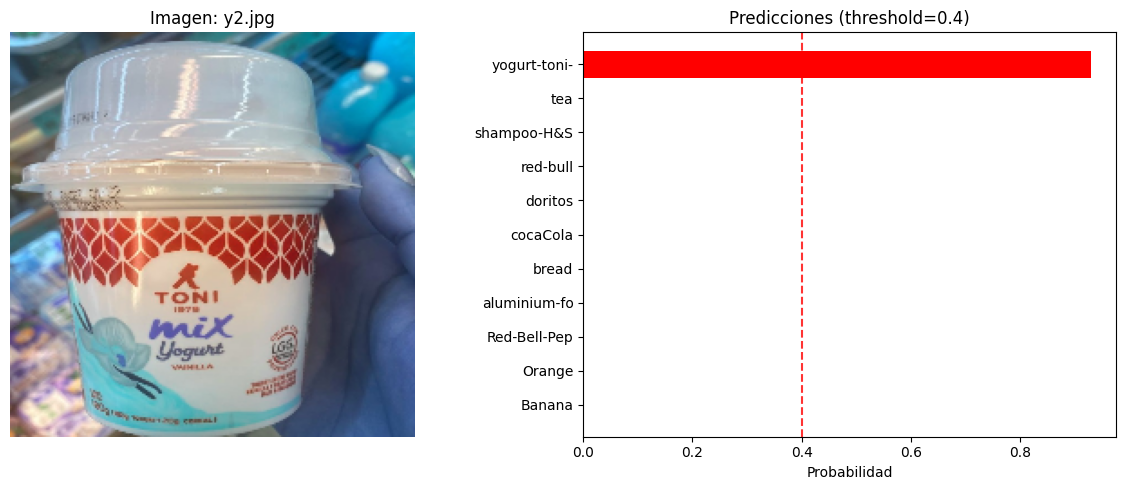

 Imagen analizada: y2.jpg
 Threshold utilizado: 0.4
\n CLASES DETECTADAS:
  1. yogurt-toni-mix: 92.9%
\n📊 TOP-3 MÁS PROBABLES:
  1. yogurt-toni-mix: 92.9%
  2. Orange: 0.0%
  3. red-bull: 0.0%
\n CLASIFICACIÓN EXITOSA!
\n============================================================
 PARA PROBAR TUS PROPIAS IMÁGENES:
   clasificar_imagen_externa('C:/ruta/completa/a/tu/imagen.jpg')
   clasificar_imagen_externa('C:/ruta/completa/a/tu/imagen.jpg', threshold=0.3)


In [46]:
# 🧪 EJEMPLO PRÁCTICO: CLASIFICAR IMAGEN EXTERNA

# Puedes cambiar esta ruta por cualquier imagen que tengas
IMAGEN_EJEMPLO = "../../Version2/ImagenesPrueba/productoHS.jpg"

# También puedes probar con estas imágenes si existen:
IMAGENES_DISPONIBLES = [
    # "../../Version2/ImagenesPrueba/banana.jpg",
    # "../../Version2/ImagenesPrueba/productoHS.jpg", 
    # "../../Version2/ImagenesPrueba/rb.jpg",
    # "../../Version2/ImagenesPrueba/prueba1.jpg",
    # "../../Dataset-SupermarketImages/Productos/Validation/doritos_cocaCola/dorito_cocaCola_011.jpeg"
    "../../Version2/ImagenesPrueba/y2.jpg",
]

print("🔍 BUSCANDO IMÁGENES DISPONIBLES...")
imagen_a_probar = None

for img_path in IMAGENES_DISPONIBLES:
    if os.path.exists(img_path):
        imagen_a_probar = img_path
        print(f" Encontrada: {img_path}")
        break
    else:
        print(f" No encontrada: {img_path}")

if imagen_a_probar:
    print(f"\\n🚀 PROBANDO CLASIFICACIÓN CON: {os.path.basename(imagen_a_probar)}")
    print("=" * 60)
    
    # Clasificar con threshold por defecto (0.4)
    resultado = clasificar_imagen_externa(imagen_a_probar)
    
    if 'error' not in resultado:
        print("\\n CLASIFICACIÓN EXITOSA!")
    else:
        print(f"\\n Error: {resultado['error']}")
        
    print("\\n" + "="*60)
    print(" PARA PROBAR TUS PROPIAS IMÁGENES:")
    print("   clasificar_imagen_externa('C:/ruta/completa/a/tu/imagen.jpg')")
    print("   clasificar_imagen_externa('C:/ruta/completa/a/tu/imagen.jpg', threshold=0.3)")
    

In [47]:
#  GUARDAR MODELO

model_name = 'modelo_cnn_transfer_learning_balanceado.h5'
model.save(model_name)

# Guardar metadatos
import json
metadata = {
    'model_type': 'MobileNetV2_Transfer_Learning',
    'image_size': IMAGE_SIZE,
    'num_classes': num_classes,
    'classes': class_names,
    'dataset_balanced': True,
    'train_samples': len(x_train),
    'val_samples': len(x_val),
    'final_metrics': {
        'train_accuracy': float(final_train_acc),
        'val_accuracy': float(final_val_acc),
        'train_loss': float(final_train_loss),
        'val_loss': float(final_val_loss),
        'hamming_loss': float(hamming),
        'subset_accuracy': float(subset_acc)
    },
    'architecture': {
        'base_model': 'MobileNetV2',
        'pretrained': 'imagenet',
        'trainable_base': False,
        'total_params': model.count_params()
    }
}

with open('metadata_transfer_learning_balanceado.json', 'w') as f:
    json.dump(metadata, f, indent=2)
